# Visualize K-Space as Directions

**Question:** Does it make sense to get initial direction from (kx, ky)?

Let's visualize what sampling from the angular spectrum actually means physically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.2)

## Setup: Simulate a Few Photons

In [2]:
# Parameters
wavelength = 0.6328  # microns
n_medium = 1.0
NA = 0.1
focal_length = 10.0  # mm

# Wave number
k = 2 * np.pi * n_medium / wavelength
k_max = k * (NA / n_medium)

print(f"k = 2π/λ = {k:.4f} rad/μm")
print(f"k_max = k × NA = {k_max:.4f} rad/μm")
print(f"Maximum angle: θ_max = arcsin(NA) = {np.degrees(np.arcsin(NA)):.2f}°")

k = 2π/λ = 9.9292 rad/μm
k_max = k × NA = 0.9929 rad/μm
Maximum angle: θ_max = arcsin(NA) = 5.74°


## Sample a Few (kx, ky) Values

Let's pick a few representative k-vectors to visualize

In [3]:
# Example k-vectors (manually chosen for clarity)
examples = [
    (0.0, 0.0, "On-axis (paraxial)"),
    (0.3, 0.0, "Small angle, +x direction"),
    (0.0, 0.5, "Medium angle, +y direction"),
    (0.4, 0.4, "Diagonal direction"),
    (k_max * 0.707, k_max * 0.707, "Maximum NA, diagonal"),
]

print("Example k-vectors:")
print(f"{'kx':>8s} {'ky':>8s} {'kz':>8s} {'|k|':>8s} {'θ (deg)':>10s} Description")
print("-" * 70)

for kx, ky, desc in examples:
    kz = np.sqrt(k**2 - kx**2 - ky**2)
    k_mag = np.sqrt(kx**2 + ky**2 + kz**2)
    theta = np.degrees(np.arctan2(np.sqrt(kx**2 + ky**2), kz))
    print(f"{kx:8.4f} {ky:8.4f} {kz:8.4f} {k_mag:8.4f} {theta:10.2f}   {desc}")

Example k-vectors:
      kx       ky       kz      |k|    θ (deg) Description
----------------------------------------------------------------------
  0.0000   0.0000   9.9292   9.9292       0.00   On-axis (paraxial)
  0.3000   0.0000   9.9246   9.9292       1.73   Small angle, +x direction
  0.0000   0.5000   9.9166   9.9292       2.89   Medium angle, +y direction
  0.4000   0.4000   9.9131   9.9292       3.27   Diagonal direction
  0.7020   0.7020   9.8794   9.9292       5.74   Maximum NA, diagonal


## Visualize: K-Space and Direction Vectors

The wave vector **k** = (kx, ky, kz) directly gives the propagation direction

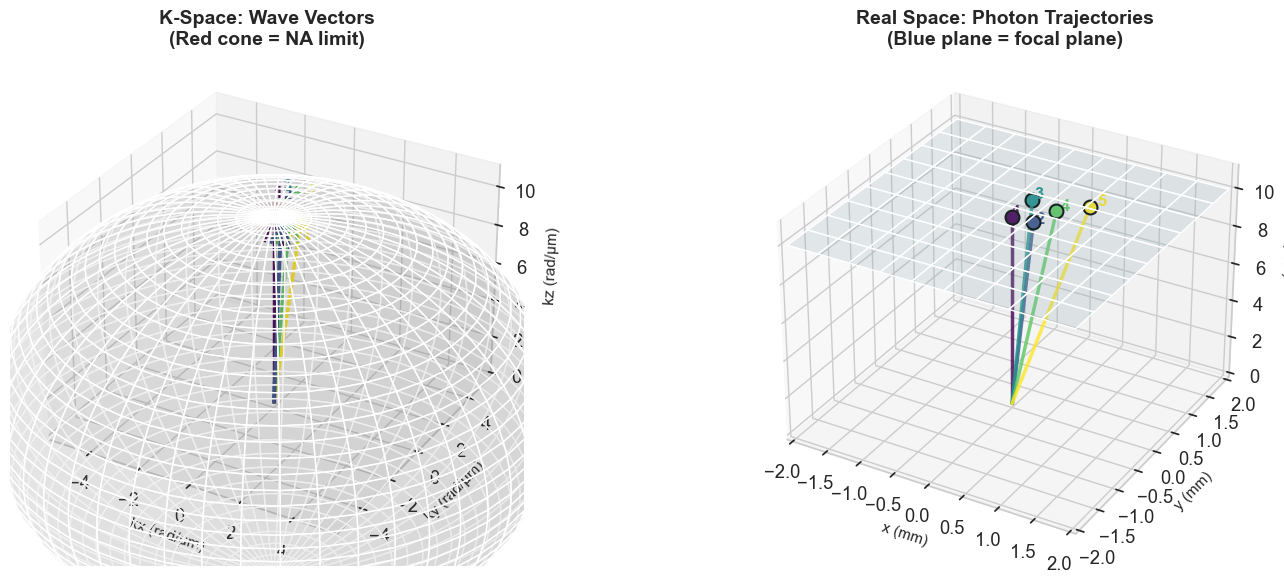


Legend:
  1. On-axis (paraxial)
  2. Small angle, +x direction
  3. Medium angle, +y direction
  4. Diagonal direction
  5. Maximum NA, diagonal


In [4]:
fig = plt.figure(figsize=(16, 6))

# Left plot: K-space representation
ax1 = fig.add_subplot(121, projection='3d')

# Draw the Ewald sphere (all valid k-vectors must lie on this sphere)
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_sphere = k * np.outer(np.cos(u), np.sin(v))
y_sphere = k * np.outer(np.sin(u), np.sin(v))
z_sphere = k * np.outer(np.ones(np.size(u)), np.cos(v))
ax1.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')

# Draw NA cone (k_transverse <= k_max)
theta_cone = np.arcsin(NA)
z_cone = np.linspace(k * np.cos(theta_cone), k, 20)
for z_val in z_cone[::3]:
    r_cone = np.sqrt(k**2 - z_val**2)
    theta_circle = np.linspace(0, 2*np.pi, 50)
    x_cone = r_cone * np.cos(theta_circle)
    y_cone = r_cone * np.sin(theta_circle)
    ax1.plot(x_cone, y_cone, z_val, 'r--', alpha=0.3, linewidth=1)

# Plot example k-vectors
colors = plt.cm.viridis(np.linspace(0, 1, len(examples)))
for i, (kx, ky, desc) in enumerate(examples):
    kz = np.sqrt(k**2 - kx**2 - ky**2)
    ax1.quiver(0, 0, 0, kx, ky, kz, color=colors[i], arrow_length_ratio=0.15, linewidth=2.5)
    ax1.text(kx*1.1, ky*1.1, kz*1.1, f"{i+1}", fontsize=12, fontweight='bold', color=colors[i])

ax1.set_xlabel('kx (rad/μm)', fontsize=11)
ax1.set_ylabel('ky (rad/μm)', fontsize=11)
ax1.set_zlabel('kz (rad/μm)', fontsize=11)
ax1.set_title('K-Space: Wave Vectors\n(Red cone = NA limit)', fontsize=14, fontweight='bold')
max_val = k * 1.1
ax1.set_xlim([-max_val/2, max_val/2])
ax1.set_ylim([-max_val/2, max_val/2])
ax1.set_zlim([0, max_val])

# Right plot: Real space directions
ax2 = fig.add_subplot(122, projection='3d')

# All photons start at origin
origin = np.array([0, 0, 0])

# Propagate in direction k/|k| to focal plane at z = f
for i, (kx, ky, desc) in enumerate(examples):
    kz = np.sqrt(k**2 - kx**2 - ky**2)
    
    # Direction vector (normalized)
    dx = kx / k
    dy = ky / k
    dz = kz / k
    
    # Propagate to focal plane: position = origin + t * direction
    # At focal plane: z = f, so t = f / dz
    t = focal_length / dz
    x_focal = t * dx
    y_focal = t * dy
    z_focal = focal_length
    
    # Draw ray
    ax2.plot([0, x_focal], [0, y_focal], [0, z_focal], 
             color=colors[i], linewidth=2.5, alpha=0.8)
    # Mark endpoint
    ax2.scatter([x_focal], [y_focal], [z_focal], 
               color=colors[i], s=100, marker='o', edgecolor='black', linewidth=1.5)
    ax2.text(x_focal*1.1, y_focal*1.1, z_focal, f"{i+1}", 
            fontsize=12, fontweight='bold', color=colors[i])

# Draw focal plane
xx, yy = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))
zz = np.ones_like(xx) * focal_length
ax2.plot_surface(xx, yy, zz, alpha=0.2, color='lightblue')

ax2.set_xlabel('x (mm)', fontsize=11)
ax2.set_ylabel('y (mm)', fontsize=11)
ax2.set_zlabel('z (mm)', fontsize=11)
ax2.set_title('Real Space: Photon Trajectories\n(Blue plane = focal plane)', fontsize=14, fontweight='bold')
ax2.set_xlim([-2, 2])
ax2.set_ylim([-2, 2])
ax2.set_zlim([0, focal_length * 1.1])

plt.tight_layout()
plt.savefig('../data/kspace_directions_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLegend:")
for i, (kx, ky, desc) in enumerate(examples):
    print(f"  {i+1}. {desc}")

## The Key Insight

**k = (kx, ky, kz) IS the direction vector!**

- The wave vector **k** points in the propagation direction
- Normalized: **d** = k/|k| = (kx/k, ky/k, kz/k)
- So yes, sampling (kx, ky) from the angular spectrum means you're directly sampling photon directions

**What the angular spectrum tells you:**
- FFT of circular aperture → decomposition into plane waves at different angles
- |FFT|² gives the intensity (weight) of each angle
- Sampling from |FFT|² weighted distribution = picking which direction each photon goes

## Where Does the Photon Land?

Starting at origin (0,0,0) with direction (dx, dy, dz), propagating to z = f:

In [5]:
print("\nFocal plane positions for example photons:\n")
print(f"{'#':>3s} {'kx':>8s} {'ky':>8s} {'dx':>8s} {'dy':>8s} {'dz':>8s} {'x_focal':>10s} {'y_focal':>10s}")
print("-" * 80)

for i, (kx, ky, desc) in enumerate(examples):
    kz = np.sqrt(k**2 - kx**2 - ky**2)
    
    # Direction
    dx = kx / k
    dy = ky / k
    dz = kz / k
    
    # Ray tracing formula: x = f * (kx/kz)
    x_ray = focal_length * (kx / kz)
    y_ray = focal_length * (ky / kz)
    
    # Fraunhofer formula: x = (λf/2π) * kx
    scale = (wavelength * focal_length) / (2 * np.pi)
    x_fraun = scale * kx
    y_fraun = scale * ky
    
    print(f"{i+1:3d} {kx:8.4f} {ky:8.4f} {dx:8.5f} {dy:8.5f} {dz:8.5f} "
          f"{x_ray:10.4f} {y_ray:10.4f}  (ray)")
    print(f"{'':3s} {'':8s} {'':8s} {'':8s} {'':8s} {'':8s} "
          f"{x_fraun:10.4f} {y_fraun:10.4f}  (Fraunhofer)")
    print()

print("\nNote: The two formulas give DIFFERENT answers!")
print("Which one is correct for diffraction?")


Focal plane positions for example photons:

  #       kx       ky       dx       dy       dz    x_focal    y_focal
--------------------------------------------------------------------------------
  1   0.0000   0.0000  0.00000  0.00000  1.00000     0.0000     0.0000  (ray)
                                                     0.0000     0.0000  (Fraunhofer)

  2   0.3000   0.0000  0.03021  0.00000  0.99954     0.3023     0.0000  (ray)
                                                     0.3021     0.0000  (Fraunhofer)

  3   0.0000   0.5000  0.00000  0.05036  0.99873     0.0000     0.5042  (ray)
                                                     0.0000     0.5036  (Fraunhofer)

  4   0.4000   0.4000  0.04029  0.04029  0.99838     0.4035     0.4035  (ray)
                                                     0.4029     0.4029  (Fraunhofer)

  5   0.7020   0.7020  0.07070  0.07070  0.99499     0.7106     0.7106  (ray)
                                                     0.7070     0.707

## Summary

**Yes, it makes perfect sense!**

1. The angular spectrum decomposes light into plane waves at different angles
2. Each (kx, ky, kz) is a wave vector pointing in a specific direction
3. Sampling from |FFT|² means picking directions weighted by the diffraction pattern
4. Each photon starts at (0,0,0) and travels in direction k/|k|

**The question is:** Once you have the direction, which formula gives the correct focal plane position?
- **Ray tracing:** x = f × (kx/kz) — treats photons as geometric rays
- **Fraunhofer:** x = (λf/2π) × kx — treats photons as diffracted waves

This is the core issue we need to resolve!